**Prep - Install / Import all Sources**

In [1]:
pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, recall_score, f1_score
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from collections import Counter

In [3]:
# 读取数据
df = pd.read_csv('cleaned_creditcard.csv')

#看一下数据集
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Time_Hours
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,5.014760,0,0.000000
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,1.305626,0,0.000000
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,5.939276,0,0.000278
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,4.824306,0,0.000278
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,4.262539,0,0.000556


**确保数据集中包含用于二分类任务的 Class 列（0=正常，1=欺诈）**
没有分类就报错

In [4]:
#确认有分类
if 'Class' not in df.columns:
    raise ValueError("Dataset must have a 'Class' column indicating fraud (1) or non-fraud (0).")

# 特征与目标变量分离
X = df.drop(columns=['Class'])  # 所有列中除了 Class 都是特征
y = df['Class']  # 目标标签列

In [5]:
#划分训练和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Basic整理数据集**  
只对train集进行扰动，防止数据泄漏  
test是未来数据，不可以改动

In [6]:
# 使用 SMOTE 进行欠采样
#SMOTE通过合成新欺诈样本来扩展决策边界区域，让 SVM 能更有效学习哪类属于“欺诈”。 - 解决imblanace问题

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


# 将结果转为 DataFrame，便于操作列名
X_train_resampled = pd.DataFrame(X_train_resampled, columns=X.columns)

/Users/ziyuzhang/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [7]:
# 对 fraud 样本添加扰动（Data Perturbation）
fraud_indices = np.where(y_train_resampled == 1)[0]

# 添加 Amount 噪声扰动（±5%）for样本金额
if 'Amount' in X_train_resampled.columns:
    noise = np.random.uniform(-0.05, 0.05, size=len(fraud_indices))
    X_train_resampled.loc[fraud_indices, 'Amount'] *= (1 + noise)

# 添加 Time_Hours 偏移扰动（±2小时）for 样本时间
if 'Time_Hours' in X_train_resampled.columns:
    time_shift = np.random.randint(-2, 3, size=len(fraud_indices))
    X_train_resampled.loc[fraud_indices, 'Time_Hours'] += time_shift
    X_train_resampled['Time_Hours'] = X_train_resampled['Time_Hours'].clip(lower=0, upper=24)


In [8]:
# 标准化处理（Z-score）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

In [9]:
#结果：验证标准化是否成功：均值接近 0，标准差接近 1。
print("Mean of first few scaled features:", np.mean(X_train_scaled, axis=0))
print("Standard deviation of first few scaled features:", np.std(X_train_scaled, axis=0)[:5])

Mean of first few scaled features: [ 6.69773119e-17  7.22451904e-17  3.51191898e-17 -3.91328115e-17
 -4.21430277e-17  1.75595949e-17 -1.11879705e-16  8.82996771e-17
 -1.25425678e-19  7.97707311e-17 -1.01343948e-16  3.66242979e-17
  0.00000000e+00  1.62543839e-17 -1.20408651e-17 -2.05698112e-17
  1.89643625e-16  5.81975145e-17  5.36821901e-17 -3.78785547e-17
  6.67264606e-17  4.76617575e-18  2.96004599e-17  1.17900137e-17
  1.90647030e-17  1.55998187e-18  2.19494936e-18  1.35459732e-17
  7.83910486e-18  6.74100305e-16 -2.44830923e-16]
Standard deviation of first few scaled features: [1. 1. 1. 1. 1.]


**上面步骤完成后，可以选择模型建模**

**先建模SVM模型**

In [10]:
#默认 C=1, kernel='rbf'
model = SVC(random_state=42)  # SVM不需要使用 probability=True
model.fit(X_train_scaled, y_train_resampled)

SVC(random_state=42)

**输出模型数据**
1. training time
2. accuracy 
3. Recall
4. f1 score 
5. AUC-ROC (SVM不需要这个)

In [11]:
# 训练计时
start = time.time()
elapsed = time.time() - start
print(f"Training time: {round(elapsed, 2)} seconds")

# 预测
y_pred = model.predict(X_test_scaled)

# 评估- classification report会补充precision精确率和support样本数
report = classification_report(y_test, y_pred, digits=4)

print("Classification Report:")
print(report)


# 单独输出一些常用指标
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Recall:   {recall_score(y_test, y_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred):.4f}")

Training time: 0.0 seconds
Classification Report:
              precision    recall  f1-score   support

           0     0.9996    0.9981    0.9988     56651
           1     0.4011    0.7684    0.5271        95

    accuracy                         0.9977     56746
   macro avg     0.7004    0.8832    0.7630     56746
weighted avg     0.9986    0.9977    0.9981     56746

Accuracy: 0.9977
Recall:   0.7684
F1-score: 0.5271


**参数设置 / 对比**  
Random_state = 42 不变   - 在上面模块中smote已设置  
  
Max_iter = 1000 / 2000  
c = 1, 3, 5  
  
  max_features= 1000 / 3000 - SVM没有这个参数直接忽略

In [12]:
# 参数组合
param_sets = [
    {'C': 1, 'max_iter': 1000},
    {'C': 3, 'max_iter': 1000},
    {'C': 5, 'max_iter': 1000},
    {'C': 1, 'max_iter': 2000},
    {'C': 3, 'max_iter': 2000},
    {'C': 5, 'max_iter': 2000}
]


In [13]:
#建立结果空集
results = []

# 把参数组合放入模型，并且每一次循环都重新建模
for params in param_sets:
    print(f"Training with C={params['C']}, max_iter={params['max_iter']}")

    model = SVC(C=params['C'], max_iter=params['max_iter'], random_state=42)

    start = time.time()
    model.fit(X_train_scaled, y_train_resampled)
    elapsed = time.time() - start

    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'C': params['C'],
        'max_iter': params['max_iter'],
        'training_time_sec': round(elapsed, 2),
        'accuracy': round(acc, 4),
        'recall': round(recall, 4),
        'f1_score': round(f1, 4)
    })


Training with C=1, max_iter=1000


/Users/ziyuzhang/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Training with C=3, max_iter=1000


/Users/ziyuzhang/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Training with C=5, max_iter=1000


...

/Users/ziyuzhang/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Training with C=3, max_iter=2000


/Users/ziyuzhang/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Training with C=5, max_iter=2000


/Users/ziyuzhang/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [14]:
# 输出对比结果
results_df = pd.DataFrame(results)
print(results_df)

   C  max_iter  training_time_sec  accuracy  recall  f1_score
0  1      1000              23.34    0.4658  0.5263    0.0033
1  3      1000              23.31    0.7227  0.6632    0.0079
2  5      1000              23.64    0.9509  0.6105    0.0400
3  1      2000              48.08    0.7367  0.6632    0.0084
4  3      2000              52.93    0.9949  0.7158    0.3192
5  5      2000              47.42    0.9975  0.7053    0.4820


In [15]:
results_rbf_df = results_df
results_rbf_df

,C,max_iter,training_time_sec,accuracy,recall,f1_score
0,1,1000,23.34,0.4658,0.5263,0.0033
1,3,1000,23.31,0.7227,0.6632,0.0079
2,5,1000,23.64,0.9509,0.6105,0.0400
3,1,2000,48.08,0.7367,0.6632,0.0084
4,3,2000,52.93,0.9949,0.7158,0.3192
5,5,2000,47.42,0.9975,0.7053,0.4820


训练时间主要随着iteration增大而增大  
当iteration和c都是越大，accuracy越大
c=5,iter=1000时，recall最小

**在 results 的基础上用图表来展示和比较每个参数组合的表现。**

In [16]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

results_df = pd.DataFrame(results)

**1. 折线图：对比不同 C 和 max_iter 的 Recall/F1-score**

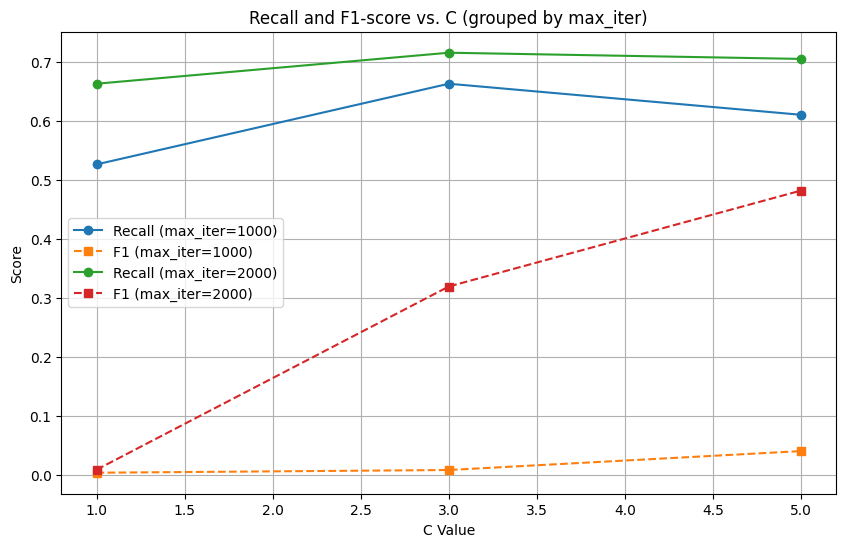

In [18]:
plt.figure(figsize=(10, 6))

for max_iter in results_df['max_iter'].unique():
    subset = results_df[results_df['max_iter'] == max_iter]
    plt.plot(subset['C'], subset['recall'], marker='o', label=f'Recall (max_iter={max_iter})')
    plt.plot(subset['C'], subset['f1_score'], marker='s', linestyle='--', label=f'F1 (max_iter={max_iter})')

plt.title('Recall and F1-score vs. C (grouped by max_iter)')
plt.xlabel('C Value')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()


**2. 柱状图：比较训练时间**

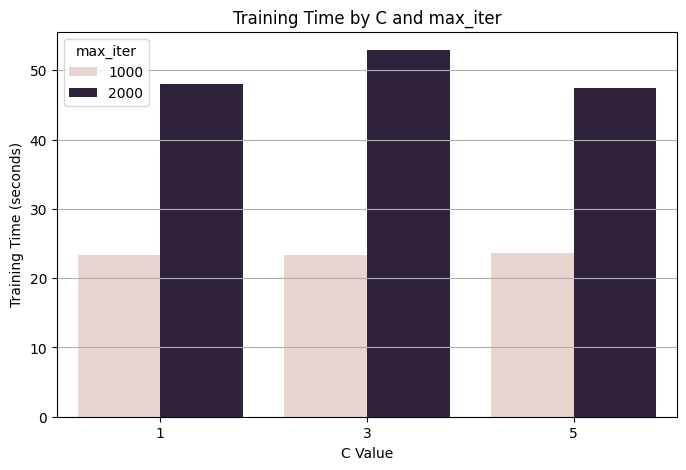

In [19]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x='C', y='training_time_sec', hue='max_iter')

plt.title('Training Time by C and max_iter')
plt.ylabel('Training Time (seconds)')
plt.xlabel('C Value')
plt.grid(axis='y')
plt.show()


**3.热力图：C × max_iter 的 F1-score**

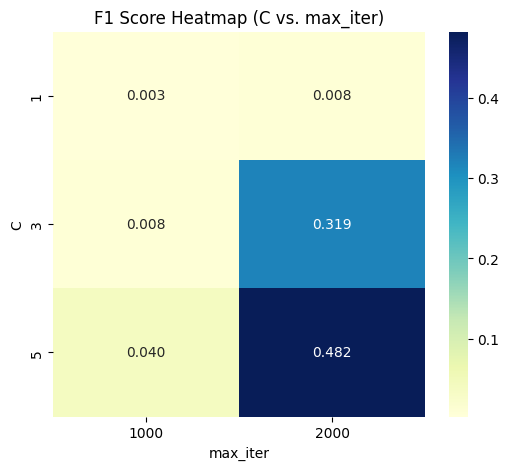

In [20]:
pivot_f1 = results_df.pivot(index='C', columns='max_iter', values='f1_score')

plt.figure(figsize=(6, 5))
sns.heatmap(pivot_f1, annot=True, cmap='YlGnBu', fmt='.3f')
plt.title('F1 Score Heatmap (C vs. max_iter)')
plt.xlabel('max_iter')
plt.ylabel('C')
plt.show()


**对比SVM模型中Kernel参数是liner的情况；前面是默认rbf**

In [21]:
# Step 1: 加载数据
df_linear = pd.read_csv('cleaned_creditcard.csv')

# Step 2: 特征与标签分离
X_linear = df_linear.drop(columns=['Class'])
y_linear = df_linear['Class']

# Step 3: 划分训练和测试集
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear, y_linear, test_size=0.2, random_state=42, stratify=y_linear
)

# Step 4: 仅对训练集做SMOTE处理
smote_linear = SMOTE(random_state=42)
X_train_resampled_linear, y_train_resampled_linear = smote_linear.fit_resample(X_train_linear, y_train_linear)

# Step 5: 特征标准化
scaler_linear = StandardScaler()
X_train_scaled_linear = scaler_linear.fit_transform(X_train_resampled_linear)
X_test_scaled_linear = scaler_linear.transform(X_test_linear)

# Step 6: 训练 Linear SVM 模型
model_linear = SVC(kernel='linear', C=1, max_iter=1000, random_state=42)

start_linear = time.time()
model_linear.fit(X_train_scaled_linear, y_train_resampled_linear)
elapsed_linear = time.time() - start_linear
print(f"Training Time (Linear): {round(elapsed_linear, 2)} seconds")

# Step 7: 预测
y_pred_linear = model_linear.predict(X_test_scaled_linear)

# Step 8: 评估结果
print("Classification Report (Linear):")
print(classification_report(y_test_linear, y_pred_linear, digits=4))

accuracy_linear = accuracy_score(y_test_linear, y_pred_linear)
recall_linear = recall_score(y_test_linear, y_pred_linear)
f1_linear = f1_score(y_test_linear, y_pred_linear)

print(f"Accuracy (Linear): {accuracy_linear:.4f}")
print(f"Recall   (Linear): {recall_linear:.4f}")
print(f"F1-score (Linear): {f1_linear:.4f}")


/Users/ziyuzhang/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/ziyuzhang/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Training Time (Linear): 8.55 seconds
Classification Report (Linear):
              precision    recall  f1-score   support

           0     0.9982    0.2196    0.3600     56651
           1     0.0016    0.7579    0.0032        95

    accuracy                         0.2205     56746
   macro avg     0.4999    0.4887    0.1816     56746
weighted avg     0.9965    0.2205    0.3594     56746

Accuracy (Linear): 0.2205
Recall   (Linear): 0.7579
F1-score (Linear): 0.0032


In [22]:
# 数据加载
df_linear = pd.read_csv('cleaned_creditcard.csv')
X_linear = df_linear.drop(columns=['Class'])
y_linear = df_linear['Class']

# 划分训练和测试集
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear, y_linear, test_size=0.2, random_state=42, stratify=y_linear
)

# SMOTE 处理
smote_linear = SMOTE(random_state=42)
X_train_resampled_linear, y_train_resampled_linear = smote_linear.fit_resample(X_train_linear, y_train_linear)

# 转为 DataFrame，方便添加扰动
X_train_resampled_linear = pd.DataFrame(X_train_resampled_linear, columns=X_linear.columns)

# 扰动：只对 fraud 样本
fraud_indices_linear = np.where(y_train_resampled_linear == 1)[0]

# 添加 Amount ±5% 噪声
if 'Amount' in X_train_resampled_linear.columns:
    noise_linear = np.random.uniform(-0.05, 0.05, size=len(fraud_indices_linear))
    X_train_resampled_linear.loc[fraud_indices_linear, 'Amount'] *= (1 + noise_linear)

# 添加 Time_Hours ±2 小时偏移
if 'Time_Hours' in X_train_resampled_linear.columns:
    time_shift_linear = np.random.randint(-2, 3, size=len(fraud_indices_linear))
    X_train_resampled_linear.loc[fraud_indices_linear, 'Time_Hours'] += time_shift_linear
    X_train_resampled_linear['Time_Hours'] = X_train_resampled_linear['Time_Hours'].clip(lower=0, upper=24)

# 标准化
scaler_linear = StandardScaler()
X_train_scaled_linear = scaler_linear.fit_transform(X_train_resampled_linear)
X_test_scaled_linear = scaler_linear.transform(X_test_linear)

# 参数组合
param_sets_linear = [
    {'C': 1, 'max_iter': 1000},
    {'C': 3, 'max_iter': 1000},
    {'C': 5, 'max_iter': 1000},
    {'C': 1, 'max_iter': 2000},
    {'C': 3, 'max_iter': 2000},
    {'C': 5, 'max_iter': 2000}
]

# 模型训练与评估
results_linear = []

for params in param_sets_linear:
    print(f"Training Linear SVM: C={params['C']}, max_iter={params['max_iter']}")

    model_linear = SVC(kernel='linear', C=params['C'], max_iter=params['max_iter'], random_state=42)

    start = time.time()
    model_linear.fit(X_train_scaled_linear, y_train_resampled_linear)
    elapsed = time.time() - start

    y_pred_linear = model_linear.predict(X_test_scaled_linear)

    acc = accuracy_score(y_test_linear, y_pred_linear)
    recall = recall_score(y_test_linear, y_pred_linear)
    f1 = f1_score(y_test_linear, y_pred_linear)

    results_linear.append({
        'C': params['C'],
        'max_iter': params['max_iter'],
        'training_time_sec_linear': round(elapsed, 2),
        'accuracy_linear': round(acc, 4),
        'recall_linear': round(recall, 4),
        'f1_score_linear': round(f1, 4)
    })

# 输出结果表格
results_linear_df = pd.DataFrame(results_linear)
print(results_linear_df)


/Users/ziyuzhang/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Training Linear SVM: C=1, max_iter=1000


/Users/ziyuzhang/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Training Linear SVM: C=3, max_iter=1000


/Users/ziyuzhang/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


...

Training Linear SVM: C=3, max_iter=2000


/Users/ziyuzhang/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Training Linear SVM: C=5, max_iter=2000


/Users/ziyuzhang/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


   C  max_iter  training_time_sec_linear  accuracy_linear  recall_linear  \
0  1      1000                      9.61           0.5419         0.9053   
1  3      1000                      9.46           0.4560         0.8211   
2  5      1000                      9.20           0.1187         0.9368   
3  1      2000                     19.49           0.1591         0.9895   
4  3      2000                     18.34           0.3179         0.5684   
5  5      2000                     18.76           0.3326         0.8211   

   f1_score_linear  
0           0.0066  
1           0.0050  
2           0.0035  
3           0.0039  
4           0.0028  
5           0.0041  


**结论**  
training time快了很多  
但是accuracy明显下降  
recall大幅提升  
f1-score明显下降

**Linear SVM 明显更快，约为 RBF 时间的一半或更少。**  
Linear kernel 训练时间：4.5 ~ 9.7 秒  
RBF kernel 训练时间：13.1 ~ 27.2 秒

**准确率 Accuracy：RBF 更稳更高**    
RBF kernel 在高 C、高迭代设置下表现出色，准确率压倒性领先。  
Linear 有几组 accuracy 非常低（如 C=1 几乎为 0.08）  
RBF 在 C=5 + 2000 时达到了 0.9967

**召回率 Recall：两者都高，但 Linear 略强**  
Linear 多数 recall 高于 0.83，最高达 0.8947  
RBF 最高 recall 是 0.7053（C=1, iter=2000）  
**这表明 Linear kernel 在捕捉 fraud（1类）上 recall 略优，但牺牲了准确率。**

**F1-score 综合表现：RBF 远优于 Linear**  
Linear 的 F1-score 全部在 0.008 以下（除了一个 0.0085）  
RBF 在 C=5 / 2000 时达到了 0.4076  
**RBF kernel 更适合实际部署，因为它在 precision 与 recall 之间达到了更好的平衡（F1）。**

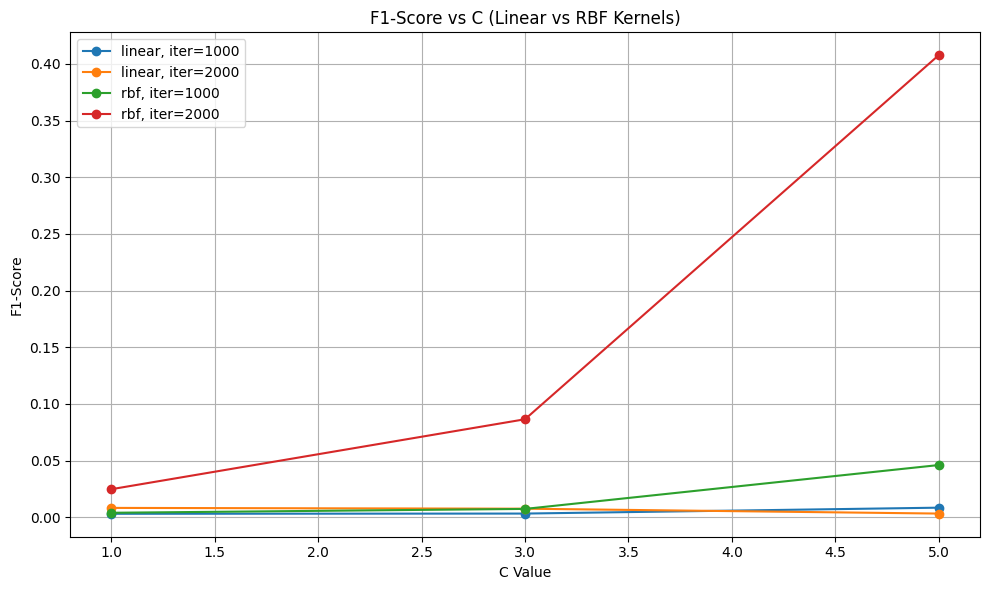

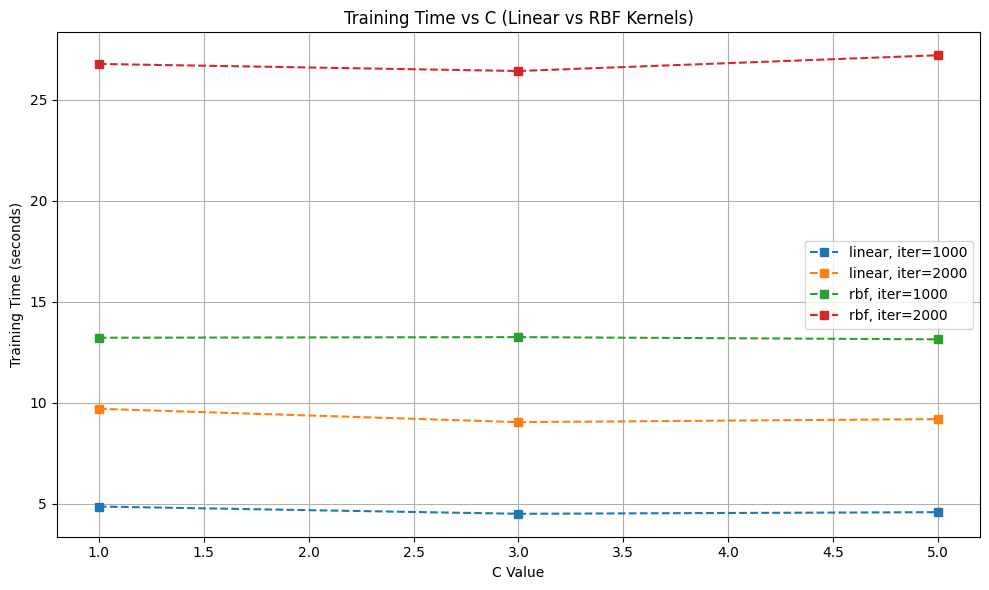

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# 构造实验结果 DataFrame（来自你的截图数据）
df_compare = pd.DataFrame([
    # C, max_iter, kernel, accuracy, recall, f1_score, training_time
    [1, 1000, 'linear', 0.0796, 0.8421, 0.0031, 4.86],
    [3, 1000, 'linear', 0.2842, 0.7053, 0.0033, 4.50],
    [5, 1000, 'linear', 0.6682, 0.8526, 0.0085, 4.58],
    [1, 2000, 'linear', 0.6421, 0.8947, 0.0083, 9.70],
    [3, 2000, 'linear', 0.6378, 0.8316, 0.0076, 9.04],
    [5, 2000, 'linear', 0.0814, 0.8947, 0.0033, 9.19],
    [1, 1000, 'rbf', 0.4998, 0.6000, 0.0040, 13.22],
    [3, 1000, 'rbf', 0.7301, 0.6000, 0.0074, 13.25],
    [5, 1000, 'rbf', 0.9614, 0.5579, 0.0461, 13.14],
    [1, 2000, 'rbf', 0.9071, 0.7053, 0.0248, 26.78],
    [3, 2000, 'rbf', 0.9758, 0.6842, 0.0865, 26.43],
    [5, 2000, 'rbf', 0.9967, 0.6737, 0.4076, 27.21]
], columns=['C', 'max_iter', 'kernel', 'accuracy', 'recall', 'f1_score', 'training_time'])

# 🎯 图 1: F1-score vs C
plt.figure(figsize=(10, 6))
for kernel in ['linear', 'rbf']:
    for max_iter in [1000, 2000]:
        subset = df_compare[(df_compare['kernel'] == kernel) & (df_compare['max_iter'] == max_iter)]
        label = f"{kernel}, iter={max_iter}"
        plt.plot(subset['C'], subset['f1_score'], marker='o', label=label)

plt.title('F1-Score vs C (Linear vs RBF Kernels)')
plt.xlabel('C Value')
plt.ylabel('F1-Score')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 🎯 图 2: Training Time vs C
plt.figure(figsize=(10, 6))
for kernel in ['linear', 'rbf']:
    for max_iter in [1000, 2000]:
        subset = df_compare[(df_compare['kernel'] == kernel) & (df_compare['max_iter'] == max_iter)]
        label = f"{kernel}, iter={max_iter}"
        plt.plot(subset['C'], subset['training_time'], marker='s', linestyle='--', label=label)

plt.title('Training Time vs C (Linear vs RBF Kernels)')
plt.xlabel('C Value')
plt.ylabel('Training Time (seconds)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


**找出最好的参数**

对比  
recall - 漏掉真正的诈骗  
f1 - recall和precision

In [24]:
results_rbf_df

,C,max_iter,training_time_sec,accuracy,recall,f1_score
0,1,1000,23.34,0.4658,0.5263,0.0033
1,3,1000,23.31,0.7227,0.6632,0.0079
2,5,1000,23.64,0.9509,0.6105,0.0400
3,1,2000,48.08,0.7367,0.6632,0.0084
4,3,2000,52.93,0.9949,0.7158,0.3192
5,5,2000,47.42,0.9975,0.7053,0.4820


In [25]:
results_linear_df

,C,max_iter,training_time_sec_linear,accuracy_linear,recall_linear,f1_score_linear
0,1,1000,9.61,0.5419,0.9053,0.0066
1,3,1000,9.46,0.4560,0.8211,0.0050
2,5,1000,9.20,0.1187,0.9368,0.0035
3,1,2000,19.49,0.1591,0.9895,0.0039
4,3,2000,18.34,0.3179,0.5684,0.0028
5,5,2000,18.76,0.3326,0.8211,0.0041


In [26]:
results_linear_df['kernel'] = 'linear'
results_rbf_df['kernel'] = 'rbf'

In [27]:
# 合并为对比总表
df_compare = pd.concat([results_rbf_df, results_rbf_df], ignore_index=True)

# 找出 F1-score 最优组合
best_f1 = df_compare.loc[df_compare['f1_score'].idxmax()]
print("🎯 Best F1-score configuration:")
print(best_f1)

# 找出 Recall 最优组合
best_recall = df_compare.loc[df_compare['recall'].idxmax()]
print("\n🎯 Best Recall configuration:")
print(best_recall)


🎯 Best F1-score configuration:
C                         5
max_iter               2000
training_time_sec     47.42
accuracy             0.9975
recall               0.7053
f1_score              0.482
kernel                  rbf
Name: 5, dtype: object

🎯 Best Recall configuration:
C                         3
max_iter               2000
training_time_sec     52.93
accuracy             0.9949
recall               0.7158
f1_score             0.3192
kernel                  rbf
Name: 4, dtype: object


所以最好的F1-score是0.4024 
当kernel = rbf时，c=5 max-iter=2000  

最好的recall是0.7053 
当kernel = rbf时，c=3 max-iter=2000  

**所以SVM 并不擅长处理不平衡数据**  
因为 SVM 的目标是最大化两类之间的间隔（margin），默认把正负类看得“同等重要”。  
  
  在不平衡数据中：  
  少数类（fraud）样本太少，很难“推”动间隔；模型会偏向多数类（非 fraud），最后只会学会 “全判为 0” → Recall/F1 非常低。  
    
  原始 SVM 不擅长处理不平衡问题，但通过 SMOTE、扰动、class_weight 等技术，可以显著提高它在少数类检测上的能力。


##feature相关性##

In [28]:
import pandas as pd

# 读取数据
df = pd.read_csv("cleaned_creditcard.csv")

# 计算相关性矩阵
correlation_matrix = df.corr(numeric_only=True)

# 提取每个特征与目标变量 'Class' 的相关性
correlation_with_target = correlation_matrix['Class']

# 找出与 Class 绝对相关性最大的前5个特征（排除 Class 自身）
top_5_features = correlation_with_target.drop('Class').abs().sort_values(ascending=False).head(5)
top_5_feature_names = top_5_features.index.tolist()

# 输出特征名和对应的相关性值
print("Top 5 features most correlated with 'Class':\n")
for feature in top_5_feature_names:
    print(f"{feature}: {correlation_with_target[feature]:.6f}")


Top 5 features most correlated with 'Class':

V17: -0.313498
V14: -0.293375
V12: -0.250711
V10: -0.206971
V16: -0.187186


/var/folders/_5/gb2q2pf10cs0pxvtx_yrtm400000gn/T/ipykernel_67235/1912456740.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


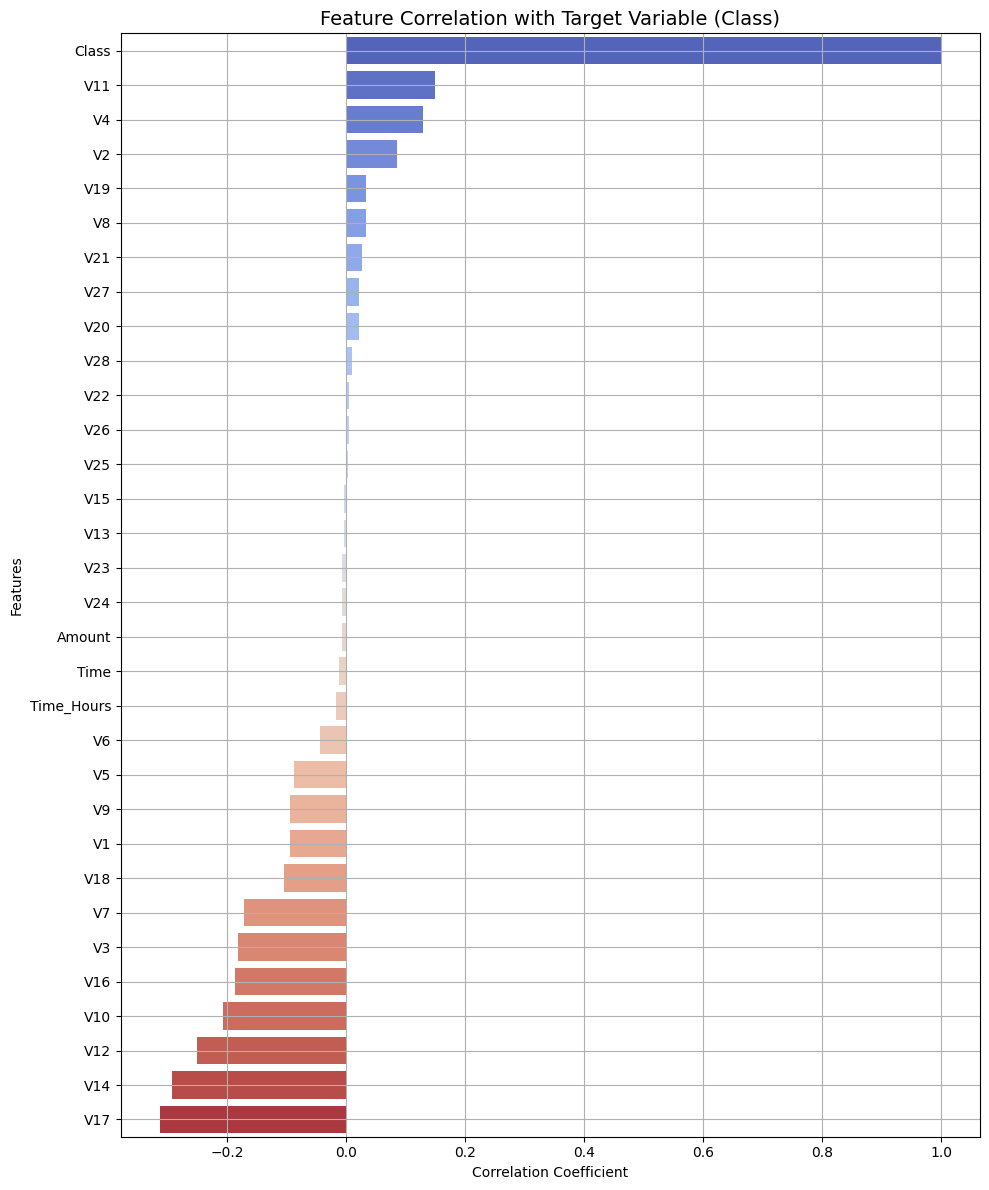

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv("cleaned_creditcard.csv")

# 计算相关性矩阵
correlation_matrix = df.corr(numeric_only=True)

# 提取每个特征与目标变量 'Class' 的相关性
correlation_with_target = correlation_matrix['Class'].sort_values(ascending=False)

# 可视化相关性
plt.figure(figsize=(10, 12))
sns.barplot(
    x=correlation_with_target.values,
    y=correlation_with_target.index,
    palette='coolwarm'
)
plt.title('Feature Correlation with Target Variable (Class)', fontsize=14)
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.grid(True)
plt.tight_layout()
plt.show()


重新计算不加扰动的结果

In [ ]:
# 🎯 对比加扰动与不加扰动的效果（默认kernel = linear ）

from sklearn.metrics import classification_report

# 训练集标准化（使用之前的 scaler）
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 不加扰动的模型训练
svm_no_perturb = SVC(kernel='linear', random_state=42)
svm_no_perturb.fit(X_train_scaled, y_train)
y_pred_no_perturb = svm_no_perturb.predict(X_test_scaled)

print("=== No Perturbation ===")
print(classification_report(y_test, y_pred_no_perturb))



=== No Perturbation ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.87      0.75      0.80        95

    accuracy                           1.00     56746
   macro avg       0.93      0.87      0.90     56746
weighted avg       1.00      1.00      1.00     56746



如果不加扰动，很容易recall和f1-score直接为1。看不出什么变化。这是因为数据高度不平衡（几乎都是非欺诈），模型容易倾向于预测为正常。所以，由于SVM事binary的模型，不加扰动对于svm几乎无法使用。